In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/mnt/nvme/zongseung/SCI/기후데이터/demand_celcius.csv")
df = df.set_index("일시")
df = df.drop("Unnamed: 0", axis=1)
df.index = pd.to_datetime(df.index)

In [3]:
import datetime as dt
cal = SouthKorea()

def holiday_weekday(data):
    holiday_data = []

    for date in data.index:

        if date.weekday() in [5, 6] or cal.is_holiday(date) is True:  # 주말 (토요일=5, 일요일=6) / 공휴일까지 포함시켜서 확인한다.
            holiday_data.append(2) # 2번은 쉬는날
        else:  # 그 외 날짜 
            holiday_data.append(1) # 안쉬는날

    data["holiday_data"] = holiday_data    
    
    return data

def get_season_by_month(month):
    asd = []
    
    for i in month: 
        if 3 <= i <= 5: 
            asd.append(1) # 봄
        elif 6 <= i <= 8:
            asd.append(2) # 여름
        elif 9 <= i <= 11:
            asd.append(3)
        else:
            asd.append(4)
    return asd

In [4]:
df["month"] = df.index.month

df_holiday = holiday_weekday(df)
df_holiday["season"] = get_season_by_month(df_holiday["month"])

In [5]:
# 더미 변수 생성 알고리즘
def select_date(data):

        dummies = pd.get_dummies(data["holiday_data"]).astype("int")
        season_dummies = pd.get_dummies(data["season"]).astype("int")
        
        data = pd.concat([data, dummies], axis = 1)
        data.drop(["holiday_data", "season"], axis=1, inplace=True)

        data.rename(columns = {1:"weekday",
        2:"weekend"}, inplace=True)

        data = pd.concat([data, season_dummies], axis = 1)

        data.rename(columns = {1:"spring",
        2:"summer",
        3:"autoum",
        4:"winter"}, inplace=True)
        
        return data

In [6]:
import datetime as dt
df.reset_index(inplace=True)
# 연,월,일 생성
df["ymd"] = df["일시"].dt.strftime('%Y-%m-%d')

# 더미 변수 생성
df = select_date(df)

Text(0.5, 1.0, '2019 jan demand data')

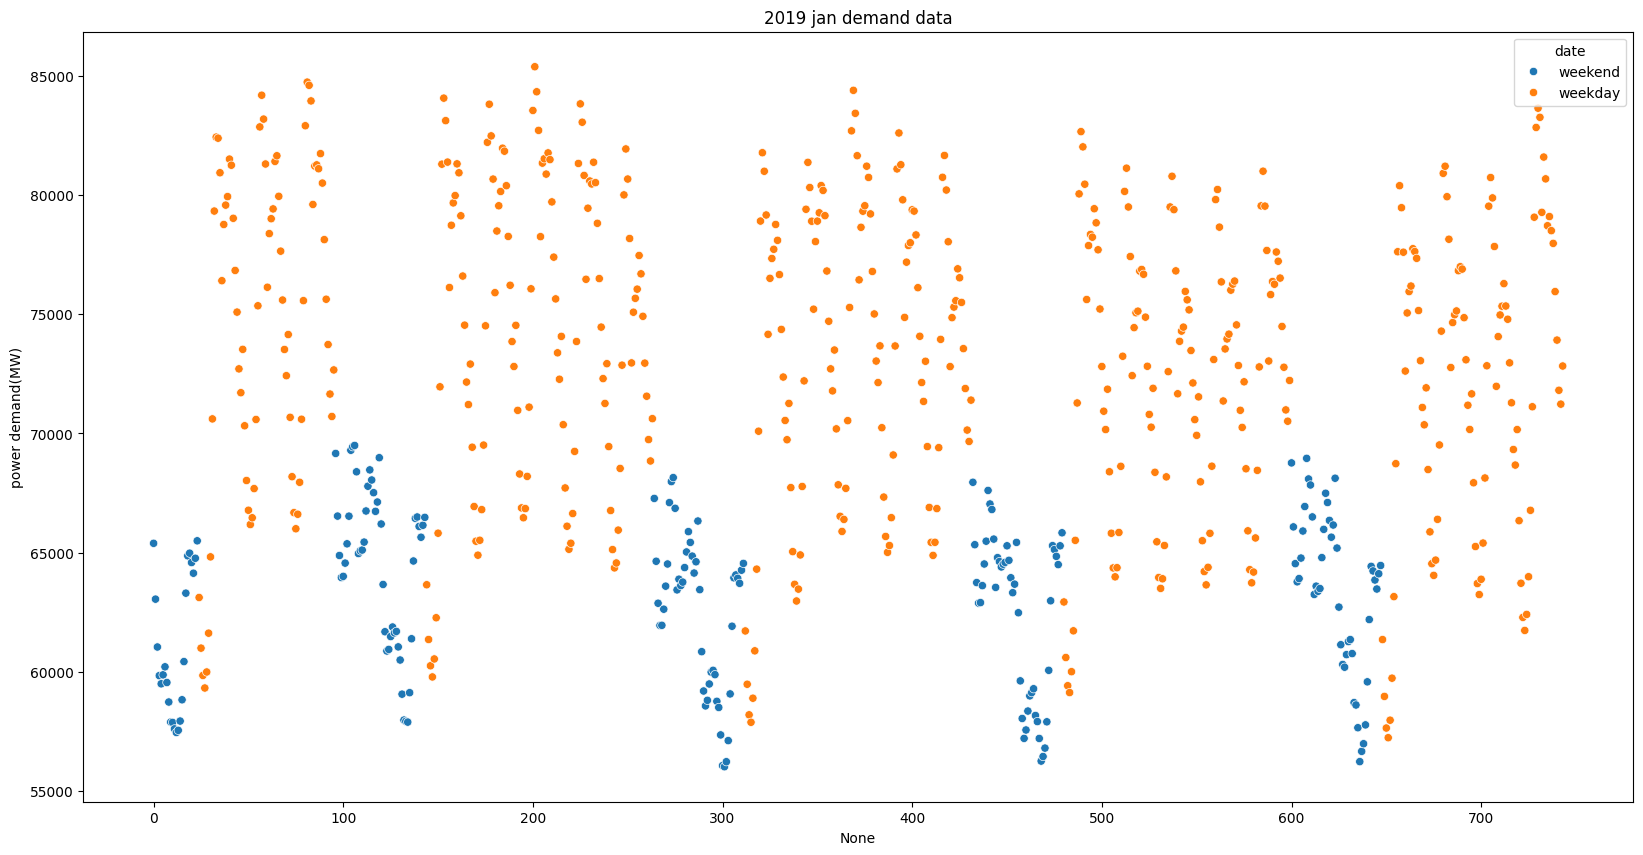

In [7]:
import seaborn as sns
df["date"] = df[["weekday", "weekend"]].idxmax(axis=1)

plt.figure(figsize=(20,10))
sns.scatterplot(x= df[:31*24].index,y=df["power demand(MW)"][:31*24], hue=df["date"][:31*24])
plt.title("2019 jan demand data")

In [8]:
from lunarcalendar import Converter, Solar, Lunar

def get_solar_date(year, lunar_month, lunar_day):
    """음력 날짜를 양력으로 변환"""
    lunar_date = Lunar(year, lunar_month, lunar_day)
    solar_date = Converter.Lunar2Solar(lunar_date)
    return pd.Timestamp(solar_date.year, solar_date.month, solar_date.day)  # pandas Timestamp 변환

# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
holiday_dict = {}
for year in range(2019, 2025):
    seollal = get_solar_date(year, 1, 1)  # 설날 본날
    chuseok = get_solar_date(year, 8, 15)  # 추석 본날

    # 연휴 포함 (전날, 당일, 다음날)
    if year==2019:
        
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"

    
    elif year == 2023:
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=2)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=3)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=4)] = "Chuseok"
    
    # 일반적으로 표기하는 경우
    else:
        # 설날
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"
        # 추석
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"

        
# `holiday_type` 컬럼 추가
df["ymd"] = pd.to_datetime(df["ymd"])
df["holiday_type"] = df["ymd"].map(holiday_dict)

## 그럼 최대 전력수요에 빗대에서 확인하자

In [9]:
# 24시간 중 최대부하 데이터 추출하기
def filtering_max_per_day(df):
    idx = df.groupby("ymd")["power demand(MW)"].idxmax()  # 최대값 인덱스
    max_per_day = df.loc[idx, ["ymd", "hm", "ta", "weekday", "weekend", "power demand(MW)", "spring", "summer","autoum", "winter"]]  # 최대값과 시간 -> "hm",	"ta", "power demand(MW)", "weekday", "weekend"
    
    max_per_day = max_per_day.rename(columns={"power demand(MW)": "max_power"})
    
    return max_per_day.reset_index(drop=True)

max_date = filtering_max_per_day(df)
max_date.set_index("ymd", inplace=True)

In [10]:
def generate_max_power_and_degree_days(df, base_temp=18.0):
    # 최대 전력수요 시점 정보 추출
    idx = df.groupby("ymd")["power demand(MW)"].idxmax()
    max_per_day = df.loc[idx, ["ymd", "hm", "ta", "weekday", "weekend",
                                "power demand(MW)", "spring", "summer", "autoum", "winter"]]
    max_per_day = max_per_day.rename(columns={"power demand(MW)": "max_power"})
    max_per_day.set_index("ymd", inplace=True)

    # 하루 최고/최저 기온 계산 → CDD, HDD 계산
    t_max = df.groupby("ymd")["ta"].max().rename("t_max")
    t_min = df.groupby("ymd")["ta"].min().rename("t_min")
    t_mean = ((t_max + t_min) / 2).rename("t_mean")
    cdd = (t_mean - base_temp).clip(lower=0).rename("CDD")
    hdd = (base_temp - t_mean).clip(lower=0).rename("HDD")

    degree_df = pd.concat([t_max, t_min, t_mean, cdd, hdd], axis=1)

    # 병합
    result = max_per_day.join(degree_df)

    return result.reset_index()



In [11]:
result_df = generate_max_power_and_degree_days(df)
print(result_df.head())

result_df.drop(["t_mean", "t_max", "t_min"] , axis=1, inplace = True)

         ymd         hm        ta  weekday  weekend  max_power  spring  \
0 2019-01-01  59.885979 -3.280564        0        1    65493.0       0   
1 2019-01-02  65.948589 -5.109383        1        0    82437.0       0   
2 2019-01-03  62.400529 -5.431358        1        0    84196.0       0   
3 2019-01-04  63.005115 -4.773677        1        0    84746.0       0   
4 2019-01-05  53.782407 -0.446138        0        1    69496.0       0   

   summer  autoum  winter     t_max     t_min    t_mean  CDD        HDD  
0       0       0       1  0.098810 -4.981931 -2.441561  0.0  20.441561  
1       0       0       1  1.213139 -6.374436 -2.580648  0.0  20.580648  
2       0       0       1  3.366217 -7.198404 -1.916093  0.0  19.916093  
3       0       0       1  3.725688 -6.715688 -1.495000  0.0  19.495000  
4       0       0       1  2.701182 -4.399030 -0.848924  0.0  18.848924  


In [12]:
result_df

,ymd,hm,ta,weekday,weekend,max_power,spring,summer,autoum,winter,CDD,HDD
0,2019-01-01,59.885979,-3.280564,0,1,65493.0,0,0,0,1,0.0,20.441561
1,2019-01-02,65.948589,-5.109383,1,0,82437.0,0,0,0,1,0.0,20.580648
2,2019-01-03,62.400529,-5.431358,1,0,84196.0,0,0,0,1,0.0,19.916093
3,2019-01-04,63.005115,-4.773677,1,0,84746.0,0,0,0,1,0.0,19.495000
4,2019-01-05,53.782407,-0.446138,0,1,69496.0,0,0,0,1,0.0,18.848924
...,...,...,...,...,...,...,...,...,...,...,...,...
2126,2024-10-27,85.027337,16.226358,0,1,59386.0,0,0,1,0,0.0,2.446561
2127,2024-10-28,74.152557,16.683915,1,0,69316.0,0,0,1,0,0.0,2.774198
2128,2024-10-29,73.509259,15.950529,1,0,69236.0,0,0,1,0,0.0,2.130922
2129,2024-10-30,69.923280,16.556958,1,0,68664.0,0,0,1,0,0.0,2.434422


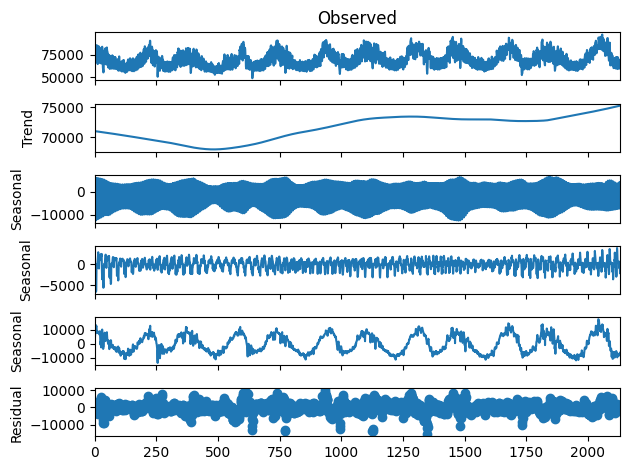

In [13]:
from statsmodels.tsa.seasonal import MSTL
res = MSTL(result_df["max_power"].values, periods=[7, 30, 365]).fit()

res.plot();

In [14]:
result_df

,ymd,hm,ta,weekday,weekend,max_power,spring,summer,autoum,winter,CDD,HDD
0,2019-01-01,59.885979,-3.280564,0,1,65493.0,0,0,0,1,0.0,20.441561
1,2019-01-02,65.948589,-5.109383,1,0,82437.0,0,0,0,1,0.0,20.580648
2,2019-01-03,62.400529,-5.431358,1,0,84196.0,0,0,0,1,0.0,19.916093
3,2019-01-04,63.005115,-4.773677,1,0,84746.0,0,0,0,1,0.0,19.495000
4,2019-01-05,53.782407,-0.446138,0,1,69496.0,0,0,0,1,0.0,18.848924
...,...,...,...,...,...,...,...,...,...,...,...,...
2126,2024-10-27,85.027337,16.226358,0,1,59386.0,0,0,1,0,0.0,2.446561
2127,2024-10-28,74.152557,16.683915,1,0,69316.0,0,0,1,0,0.0,2.774198
2128,2024-10-29,73.509259,15.950529,1,0,69236.0,0,0,1,0,0.0,2.130922
2129,2024-10-30,69.923280,16.556958,1,0,68664.0,0,0,1,0,0.0,2.434422


In [15]:
len(result_df)

2131

In [17]:
observed = res.observed
trend = res.trend
seasonal = res.seasonal  # shape: (n_samples, n_seasons)

# 전체 계절 성분 합산
seasonal_sum = seasonal.sum(axis=1)

# Residual 계산
residual = observed - trend - seasonal_sum
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# train - (val) - test 로 분할 실시한다. 7:1.5:1.5
## AR의 모형을 기반으로 분할 -> 예는 
# 분할 인덱스
total_len = len(result_df)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)
##################################3#################3#################3#################3#################3#################3
trend_train = trend[:val_end] #이를 기반으로 AR 모형 생성
trend_test = trend[val_end:] #이를 기반으로 AR 모형 생성
#### multiple-seasonality + 외부변수 기반 예측 사용 ####
result_df["multiple_season"] = seasonal_sum
result_df1 = result_df[["hm", "ta", "weekday", "weekend",	"spring", "summer", "autoum", "winter", "CDD", "HDD","multiple_season"]]

train_df = result_df1.iloc[:train_end].copy()
val_df = result_df1.iloc[train_end:val_end].copy()
test_df = result_df1.iloc[val_end:].copy()

#----- 잔차 모델링 ----------
## residual 사용 -> 이때 자기상관성이 있는지 모델링
train_residual = residual[:train_end].copy()
val_residual = residual[train_end:val_end].copy()
test_residual = residual[val_end:].copy()

In [18]:
from statsmodels.tsa.ar_model import ar_select_order

# 예: trend_train 기반으로 AR 차수 선택
sel = ar_select_order(trend_train, maxlag=15, ic='aic', old_names=False)
print("추천 lag:", sel.ar_lags)


추천 lag: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


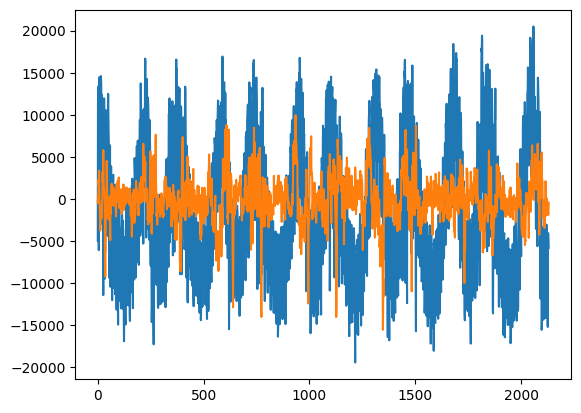

In [19]:
plt.plot(seasonal_sum);
plt.plot(residual);

In [78]:
from pmdarima import auto_arima

model = auto_arima(trend_train,
                   start_p=0, start_q=0,
                   max_p=5, max_q=5,
                   seasonal=False,
                   d=1,            # 자동 추정
                   stepwise=True,
                   trace=True)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11694.110, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11736.179, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-6770.648, Time=0.70 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-8357.538, Time=0.90 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-8345.898, Time=2.21 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-6768.100, Time=3.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-7138.959, Time=0.98 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-8356.629, Time=2.72 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-8355.335, Time=0.29 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 12.711 seconds


In [56]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

def rolling_arima_forecast(train_series, test_series, p=2, d=1, q=1, window_size=7):
    """
    train_series: 학습 시계열 (numpy or Series)
    test_series: 테스트 시계열 (예측 대상)
    p, d, q: ARIMA 차수
    window_size: None이면 누적 방식, 값 주면 슬라이딩 윈도우
    """
    history = list(train_series)
    preds = []

    for t in range(len(test_series)):
        # 학습 구간 설정
        if window_size is not None:
            train_window = history[-window_size:]
        else:
            train_window = history

        model = ARIMA(train_window, order=(p, d, q))
        model_fit = model.fit()

        # 1-step ahead forecast
        pred = model_fit.forecast()[0]
        preds.append(pred)

        # 실제값 추가 (실제 예측 환경 가정)
        history.append(test_series[t])

    return np.array(preds)



In [57]:
# train = trend[:val_end], test = trend[val_end:]
arima_preds = rolling_arima_forecast(trend[:val_end], trend[val_end:], p=2, d=1, q=1)


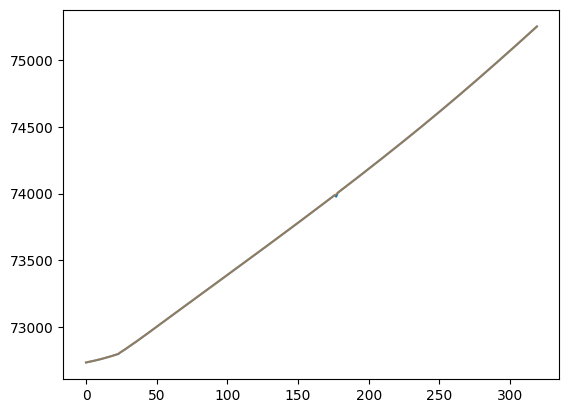

In [58]:
plt.plot(arima_preds)
plt.plot(trend_test, alpha=0.5)

In [22]:
# 슬라이딩 윈도우
def sliding_window(datax, datay, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datay[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

# 1차 표준화
from sklearn.preprocessing import MinMaxScaler
mnx1 = MinMaxScaler()
mny1 = MinMaxScaler()

scaled_train_x1 = mnx1.fit_transform(train_df.drop("multiple_season", axis=1))
scaled_val_x1 = mnx1.transform(val_df.drop("multiple_season", axis=1))
scaled_test_x1 = mnx1.transform(test_df.drop("multiple_season", axis=1))

# 올바르게
scaled_train_y1 = mny1.fit_transform(train_df[["multiple_season"]]).flatten()
scaled_val_y1   = mny1.transform(  val_df[["multiple_season"]]).flatten()
scaled_test_y1  = mny1.transform( test_df[["multiple_season"]]).flatten()

# 3) 스케일된 배열에 슬라이딩 윈도우 적용
window_size = 7
Xtr, ytr = sliding_window(scaled_train_x1, scaled_train_y1, window_size)
Xva, yva = sliding_window(scaled_val_x1,   scaled_val_y1,   window_size)
Xte, yte = sliding_window(scaled_test_x1,  scaled_test_y1,  window_size)


##############################################################################################################
mnx2 = MinMaxScaler()
mny2 = MinMaxScaler()

# 
# 슬라이딩 윈도우
def sliding_window_residual(datax, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datax[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

scaled_train_residual = mnx2.fit_transform(train_residual.reshape(-1,1))
scaled_val_residual = mnx2.transform(val_residual.reshape(-1,1))
scaled_test_residual = mnx2.transform(test_residual.reshape(-1,1))

Xtr1, ytr1 = sliding_window_residual(scaled_train_residual, window_size=7)
Xva1, yva1 = sliding_window_residual(scaled_val_residual,   window_size=7)
Xte1, yte1 = sliding_window_residual(scaled_test_residual,  window_size=7)

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from bayes_opt import BayesianOptimization
from torch.optim.lr_scheduler import StepLR
import math

device = "cuda" if torch.cuda.is_available() else "cpu"

#############################################
# 1. LSTM-only 모델 정의
#############################################
class LSTM_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units,
                 lstm_dropout_rate, dense_dropout_rate, input_features):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=units,
            num_layers=lstm_layers,
            batch_first=True
        )
        self.lstm_dropout = nn.Dropout(lstm_dropout_rate)
        self.dense_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(units if i == 0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)
        ])
        self.output_layer = nn.Linear(
            dense_units if dense_layers > 0 else units, 1
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.lstm_dropout(x[:, -1, :])
        for layer in self.dense_layers:
            x = layer(x)
        return self.output_layer(x)

#############################################
# 2. DataLoader 생성
#############################################
def create_dataloader(X, Y, batch_size):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=False, num_workers=4, pin_memory=True)

#############################################
# 3. Fitness 함수 (LSTM-only)
#############################################
def fitness_function(params, X_train, Y_train, X_val, Y_val, device):
    lstm_layers  = int(round(params['lstm_layers']))
    dense_layers = int(round(params['dense_layers']))
    units        = int(round(params['units']))
    dense_units  = int(round(params['dense_units']))
    lr           = params['lr']
    lstm_dr      = params['lstm_dr']
    dense_dr     = params['dense_dr']
    batch_size   = int(round(params['batch_size']))

    model = LSTM_Model(
        lstm_layers, dense_layers, units, dense_units,
        lstm_dr, dense_dr,
        input_features=X_train.shape[2]
    ).to(device)

    criterion = nn.MSELoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    train_loader = create_dataloader(X_train, Y_train, batch_size)

    model.train()
    for _ in range(30):
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_x   = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_y   = torch.tensor(Y_val, dtype=torch.float32).to(device)
        val_loss = criterion(model(val_x), val_y).item()

    return -val_loss  # maximize용

#############################################
# 4. Bayesian Optimization 설정 및 실행
#############################################
pbounds = {
    'lstm_layers':  (1, 2),
    'dense_layers': (1, 3),
    'units':        (16, 128),
    'dense_units':  (16, 128),
    'lr':           (1e-4, 1e-2),
    'lstm_dr':      (0.1, 0.5),
    'dense_dr':     (0.1, 0.5),
    'batch_size':   (16, 128)
}

optimizer_bo = BayesianOptimization(
    f=lambda **kwargs: fitness_function(kwargs, Xtr1, ytr1, Xva1, yva1, device),
    pbounds=pbounds,
    random_state=42,
    verbose=2
)
optimizer_bo.maximize(init_points=5, n_iter=25)

#############################################
# 5. 최적 파라미터로 최종 모델 학습
#############################################
best = optimizer_bo.max['params']
best_params = {
    'lstm_layers':  int(round(best['lstm_layers'])),
    'dense_layers': int(round(best['dense_layers'])),
    'units':        int(round(best['units'])),
    'dense_units':  int(round(best['dense_units'])),
    'lr':           best['lr'],
    'lstm_dr':      best['lstm_dr'],
    'dense_dr':     best['dense_dr'],
    'batch_size':   int(round(best['batch_size']))
}

print("Best parameters:", best_params)

# Final training
final_model = LSTM_Model(
    best_params['lstm_layers'],
    best_params['dense_layers'],
    best_params['units'],
    best_params['dense_units'],
    best_params['lstm_dr'],
    best_params['dense_dr'],
    input_features=Xtr1.shape[2]  # 수정
).to(device)

optimizer_final = optim.Adam(final_model.parameters(), lr=best_params['lr'])
scheduler = StepLR(optimizer_final, step_size=10, gamma=0.5)

train_loader = create_dataloader(Xtr1, ytr1, best_params['batch_size'])
val_loader   = create_dataloader(Xva1, yva1, best_params['batch_size'])
test_loader  = create_dataloader(Xte1, yte1, best_params['batch_size'])

# Early stopping setup
best_val, counter, patience = float('inf'), 0, 10

for epoch in range(1, 151):
    final_model.train()
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer_final.zero_grad()
        loss = nn.MSELoss()(final_model(bx), by)
        loss.backward()
        optimizer_final.step()
    scheduler.step()

    final_model.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += nn.MSELoss()(final_model(bx), by).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch:3d}: Val Loss={val_loss:.4f}")

    if val_loss < best_val:
        best_val, counter = val_loss, 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Test 평가
final_model.eval()
test_loss = 0
with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        test_loss += nn.MSELoss()(final_model(bx), by).item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")


|   iter    |  target   | batch_... | dense_dr  | dense_... | dense_... |    lr     |  lstm_dr  | lstm_l... |   units   |
-------------------------------------------------------------------------------------------------------------------------
| 1         | -3.779e-0 | 57.95     | 0.4803    | 2.464     | 83.05     | 0.001645  | 0.1624    | 1.058     | 113.0     |
| 2         | -7.926e-0 | 83.32     | 0.3832    | 1.041     | 124.6     | 0.008341  | 0.1849    | 1.182     | 36.54     |
| 3         | -0.000106 | 50.08     | 0.3099    | 1.864     | 48.62     | 0.006157  | 0.1558    | 1.292     | 57.03     |
| 4         | -0.000416 | 67.08     | 0.4141    | 1.399     | 73.59     | 0.005965  | 0.1186    | 1.608     | 35.1      |
| 5         | -0.000396 | 23.29     | 0.4796    | 2.931     | 106.5     | 0.003116  | 0.1391    | 1.684     | 65.3      |
| 6         | -0.000193 | 82.12     | 0.2136    | 2.692     | 125.9     | 0.00129   | 0.1071    | 1.79      | 37.35     |
| 7         | -8.075e-0 

In [30]:
best = optimizer_bo.max['params']
best_params = {
    'lstm_layers':  int(round(best['lstm_layers'])),
    'dense_layers': int(round(best['dense_layers'])),
    'units':        int(round(best['units'])),
    'dense_units':  int(round(best['dense_units'])),
    'lr':           best['lr'],
    'lstm_dr':      best['lstm_dr'],
    'dense_dr':     best['dense_dr'],
    'batch_size':   int(round(best['batch_size']))
}
print("Best parameters:", best_params)

# 최종 모델 세팅
model = LSTM_Model(
    best_params['lstm_layers'],
    best_params['dense_layers'],
    best_params['units'],
    best_params['dense_units'],
    best_params['lstm_dr'],
    best_params['dense_dr'],
    input_features = Xtr1.shape[2]
).to(device)

optimizer_final = optim.Adam(model.parameters(), lr=best_params['lr'])
scheduler       = StepLR(optimizer_final, step_size=10, gamma=0.5)

train_loader = create_dataloader(Xtr1, ytr1, best_params['batch_size'])
val_loader   = create_dataloader(Xva1, yva1, best_params['batch_size'])
test_loader  = create_dataloader(Xte1, yte1, best_params['batch_size'])

train_losses, val_losses = [], []
best_val, counter, patience = float('inf'), 0, 10

for epoch in range(1, 151):
    # Training
    model.train()
    batch_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer_final.zero_grad()
        loss = nn.MSELoss()(model(bx), by)
        loss.backward()
        optimizer_final.step()
        batch_loss += loss.item()
    scheduler.step()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += nn.MSELoss()(model(bx), by).item()
    val_loss /= len(val_loader)

    train_losses.append(batch_loss / len(train_loader))
    val_losses.append(val_loss)

    print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val:
        best_val, counter = val_loss, 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Test 평가 및 예측
model.eval()
test_loss = 0.0
all_preds = []
with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        preds = model(bx)
        all_preds.append(preds.cpu().numpy())
        test_loss += nn.MSELoss()(preds, by).item()
test_loss /= len(test_loader)
test_preds = np.concatenate(all_preds, axis=0)

print(f"Test Loss: {test_loss:.4f}")
print("Test Predictions (first 10):", test_preds[:10])

Best parameters: {'lstm_layers': 1, 'dense_layers': 1, 'units': 110, 'dense_units': 77, 'lr': 0.0018083807421457963, 'lstm_dr': 0.432675083248242, 'dense_dr': 0.3208493785136678, 'batch_size': 58}


Epoch   1 | Train Loss: 0.0922 | Val Loss: 0.0053
Epoch   2 | Train Loss: 0.0232 | Val Loss: 0.0053
Epoch   3 | Train Loss: 0.0180 | Val Loss: 0.0047
Epoch   4 | Train Loss: 0.0155 | Val Loss: 0.0043
Epoch   5 | Train Loss: 0.0145 | Val Loss: 0.0049
Epoch   6 | Train Loss: 0.0123 | Val Loss: 0.0027
Epoch   7 | Train Loss: 0.0108 | Val Loss: 0.0050
Epoch   8 | Train Loss: 0.0100 | Val Loss: 0.0018
Epoch   9 | Train Loss: 0.0095 | Val Loss: 0.0018
Epoch  10 | Train Loss: 0.0082 | Val Loss: 0.0015
Epoch  11 | Train Loss: 0.0076 | Val Loss: 0.0011
Epoch  12 | Train Loss: 0.0066 | Val Loss: 0.0009
Epoch  13 | Train Loss: 0.0063 | Val Loss: 0.0013
Epoch  14 | Train Loss: 0.0062 | Val Loss: 0.0008
Epoch  15 | Train Loss: 0.0060 | Val Loss: 0.0009
Epoch  16 | Train Loss: 0.0056 | Val Loss: 0.0014
Epoch  17 | Train Loss: 0.0054 | Val Loss: 0.0010
Epoch  18 | Train Loss: 0.0051 | Val Loss: 0.0006
Epoch  19 | Train Loss: 0.0051 | Val Loss: 0.0004
Epoch  20 | Train Loss: 0.0049 | Val Loss: 0.0010


In [36]:
inverse_pred = mnx2.inverse_transform(test_preds.reshape(-1,1))
inverse_real = mnx2.inverse_transform(yte1.reshape(-1,1))

[[-2970.9905   ]
 [-4924.392    ]
 [-6282.5107   ]
 [-4013.187    ]
 [-3383.3076   ]
 [-2708.3171   ]
 [-3413.3696   ]
 [-2234.4097   ]
 [-3370.252    ]
 [-5600.882    ]
 [-3891.6716   ]
 [-2776.6494   ]
 [-1943.0197   ]
 [-2131.423    ]
 [-1270.1611   ]
 [  276.7274   ]
 [  298.68655  ]
 [ -558.16614  ]
 [-1389.4657   ]
 [-1069.5386   ]
 [ -964.2782   ]
 [ -190.66895  ]
 [   81.46003  ]
 [ -808.6295   ]
 [-2590.4954   ]
 [-2874.5051   ]
 [-2886.2412   ]
 [-1629.1154   ]
 [ -396.5326   ]
 [ -447.34982  ]
 [ 3314.0781   ]
 [ 5508.159    ]
 [ 3090.2126   ]
 [-1399.9982   ]
 [-2037.0586   ]
 [-1472.043    ]
 [-1257.101    ]
 [ -666.806    ]
 [-1138.9644   ]
 [ 1589.8325   ]
 [ 3537.5115   ]
 [ 3531.7578   ]
 [-2699.444    ]
 [-3898.2207   ]
 [-3057.3206   ]
 [-2537.0317   ]
 [-4076.8948   ]
 [-4361.3936   ]
 [-6398.052    ]
 [-3509.3303   ]
 [-1119.1938   ]
 [-4189.239    ]
 [-4265.073    ]
 [-2463.9163   ]
 [-2854.8523   ]
 [-2144.424    ]
 [-1631.4941   ]
 [-1774.3245   ]
 [-1463.5623  

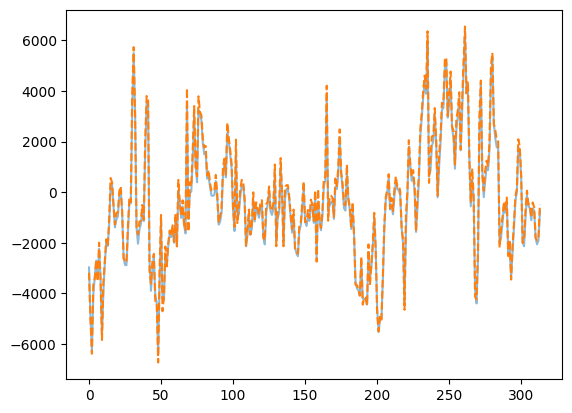

In [44]:
plt.plot(inverse_pred, alpha=0.5)
plt.plot(inverse_real, "--")

# 오차 그래프 생성
residual = inverse_real - inverse_pred
print(inverse_pred)
print(inverse_real)

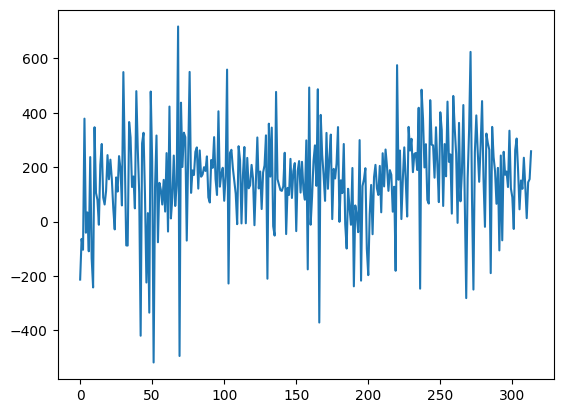

In [42]:
plt.plot(residual)

|   iter    |  target   | batch_... | dense_dr  | dense_... | dense_... |    lr     |  lstm_dr  | lstm_l... |   units   |
-------------------------------------------------------------------------------------------------------------------------
| 1         | -0.06304  | 57.95     | 0.4803    | 2.464     | 166.1     | 0.001645  | 0.1624    | 1.116     | 226.0     |
| 2         | -0.06039  | 83.32     | 0.3832    | 1.041     | 249.3     | 0.008341  | 0.1849    | 1.364     | 73.08     |
| 3         | -0.06768  | 50.08     | 0.3099    | 1.864     | 97.24     | 0.006157  | 0.1558    | 1.584     | 114.1     |
| 4         | -0.06052  | 67.08     | 0.4141    | 1.399     | 147.2     | 0.005965  | 0.1186    | 2.215     | 70.2      |
| 5         | -0.07915  | 23.29     | 0.4796    | 2.931     | 213.1     | 0.003116  | 0.1391    | 2.368     | 130.6     |
| 6         | -0.06077  | 68.68     | 0.2297    | 2.487     | 149.0     | 0.009148  | 0.3601    | 1.424     | 68.92     |
| 7         | -0.05089  

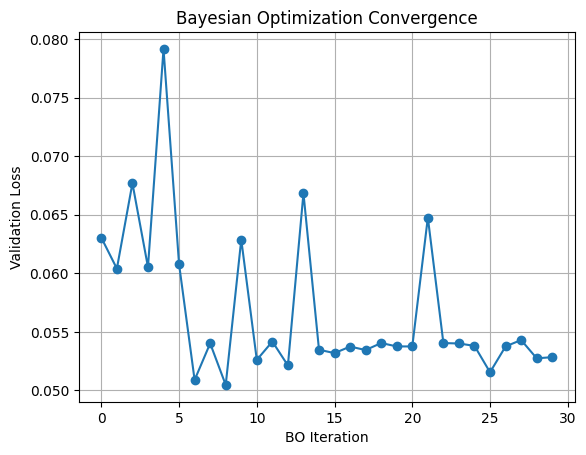

Best parameters: {'lstm_layers': 3, 'dense_layers': 2, 'units': 253, 'dense_units': 38, 'lr': 0.009094467136372866, 'lstm_dr': 0.46669827789097607, 'dense_dr': 0.1733900204618001, 'batch_size': 120}
Epoch   1 | Train Loss: 0.1366 | Val Loss: 0.0483
Epoch   2 | Train Loss: 0.0581 | Val Loss: 0.0521
Epoch   3 | Train Loss: 0.0571 | Val Loss: 0.0535
Epoch   4 | Train Loss: 0.0567 | Val Loss: 0.0520
Epoch   5 | Train Loss: 0.0583 | Val Loss: 0.0501
Epoch   6 | Train Loss: 0.0579 | Val Loss: 0.0486
Epoch   7 | Train Loss: 0.0569 | Val Loss: 0.0483
Epoch   8 | Train Loss: 0.0548 | Val Loss: 0.0485
Epoch   9 | Train Loss: 0.0526 | Val Loss: 0.0488
Epoch  10 | Train Loss: 0.0516 | Val Loss: 0.0494
Epoch  11 | Train Loss: 0.0507 | Val Loss: 0.0497
Early stopping at epoch 11
Test Loss: 0.0633
Test Predictions (first 10): [[0.55449873]
 [0.5543095 ]
 [0.55433226]
 [0.55424607]
 [0.5543364 ]
 [0.5543437 ]
 [0.5543865 ]
 [0.55445373]
 [0.5542317 ]
 [0.55423105]]


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
import numpy as np
import math

# GPU 세팅
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled   = True

#############################################
# 1. LSTM-only 모델 정의
#############################################
class LSTM_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units,
                 lstm_dropout_rate, dense_dropout_rate, input_features):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_features,
                            hidden_size=units,
                            num_layers=lstm_layers,
                            batch_first=True)
        self.lstm_dropout = nn.Dropout(lstm_dropout_rate)
        self.dense_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(units if i==0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)
        ])
        self.output_layer = nn.Linear(
            dense_units if dense_layers>0 else units, 1
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.lstm_dropout(x[:, -1, :])
        for layer in self.dense_layers:
            x = layer(x)
        return self.output_layer(x)

#############################################
# 2. DataLoader 생성
#############################################
def create_dataloader(X, Y, batch_size):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32)
    )
    return DataLoader(ds,
                      batch_size=batch_size,
                      shuffle=False,
                      num_workers=0,
                      pin_memory=True)

#############################################
# 3. Fitness 함수 (LSTM-only)
#############################################
def fitness_function(params, X_tr, y_tr, X_va, y_va, device):
    # 파라미터 언팩
    lstm_layers  = int(round(params['lstm_layers']))
    dense_layers = int(round(params['dense_layers']))
    units        = int(round(params['units']))
    dense_units  = int(round(params['dense_units']))
    lr           = params['lr']
    lstm_dr      = params['lstm_dr']
    dense_dr     = params['dense_dr']
    batch_size   = int(round(params['batch_size']))

    # 모델 초기화
    model = LSTM_Model(
        lstm_layers, dense_layers, units, dense_units,
        lstm_dr, dense_dr,
        input_features=X_tr.shape[2]
    ).to(device)

    criterion = nn.MSELoss()
    opt       = optim.Adam(model.parameters(), lr=lr)
    loader    = create_dataloader(X_tr, y_tr, batch_size)

    # 간단 학습 (30 steps)
    model.train()
    for _ in range(30):
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            opt.step()

    # 검증 손실 계산
    model.eval()
    with torch.no_grad():
        vx = torch.tensor(X_va, dtype=torch.float32).to(device)
        vy = torch.tensor(y_va, dtype=torch.float32).to(device)
        val_loss = criterion(model(vx), vy).item()

    # BO는 최댓값을 찾으므로 음수 반환
    return -val_loss

#############################################
# 4. Bayesian Optimization 설정 및 실행
#############################################
pbounds = {
    'lstm_layers':  (1, 3),
    'dense_layers': (1, 3),
    'units':        (32, 256),
    'dense_units':  (32, 256),
    'lr':           (1e-4, 1e-2),
    'lstm_dr':      (0.1, 0.5),
    'dense_dr':     (0.1, 0.5),
    'batch_size':   (16, 128),
}

optimizer_bo = BayesianOptimization(
    f=lambda **kw: fitness_function(kw, Xtr, ytr, Xva, yva, device),
    pbounds=pbounds,
    random_state=42,
    verbose=2
)
optimizer_bo.maximize(init_points=5, n_iter=25)

# BO 수렴 곡선 시각화
iters          = list(range(len(optimizer_bo.res)))
val_losses_bo  = [-r['target'] for r in optimizer_bo.res]
plt.figure()
plt.plot(iters, val_losses_bo, marker='o')
plt.xlabel('BO Iteration')
plt.ylabel('Validation Loss')
plt.title('Bayesian Optimization Convergence')
plt.grid(True)
plt.show()

#############################################
# 5. 최적 파라미터로 최종 학습 & 평가
#############################################
best = optimizer_bo.max['params']
best_params = {
    'lstm_layers':  int(round(best['lstm_layers'])),
    'dense_layers': int(round(best['dense_layers'])),
    'units':        int(round(best['units'])),
    'dense_units':  int(round(best['dense_units'])),
    'lr':           best['lr'],
    'lstm_dr':      best['lstm_dr'],
    'dense_dr':     best['dense_dr'],
    'batch_size':   int(round(best['batch_size']))
}
print("Best parameters:", best_params)

# 최종 모델 세팅
model = LSTM_Model(
    best_params['lstm_layers'],
    best_params['dense_layers'],
    best_params['units'],
    best_params['dense_units'],
    best_params['lstm_dr'],
    best_params['dense_dr'],
    input_features = Xtr.shape[2]
).to(device)

optimizer_final = optim.Adam(model.parameters(), lr=best_params['lr'])
scheduler       = StepLR(optimizer_final, step_size=10, gamma=0.5)

train_loader = create_dataloader(Xtr, ytr, best_params['batch_size'])
val_loader   = create_dataloader(Xva, yva, best_params['batch_size'])
test_loader  = create_dataloader(Xte, yte, best_params['batch_size'])

train_losses, val_losses = [], []
best_val, counter, patience = float('inf'), 0, 10

for epoch in range(1, 151):
    # Training
    model.train()
    batch_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer_final.zero_grad()
        loss = nn.MSELoss()(model(bx), by)
        loss.backward()
        optimizer_final.step()
        batch_loss += loss.item()
    scheduler.step()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            val_loss += nn.MSELoss()(model(bx), by).item()
    val_loss /= len(val_loader)

    train_losses.append(batch_loss / len(train_loader))
    val_losses.append(val_loss)

    print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val:
        best_val, counter = val_loss, 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Test 평가 및 예측
model.eval()
test_loss = 0.0
all_preds = []
with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        preds = model(bx)
        all_preds.append(preds.cpu().numpy())
        test_loss += nn.MSELoss()(preds, by).item()
test_loss /= len(test_loader)
test_preds = np.concatenate(all_preds, axis=0)

print(f"Test Loss: {test_loss:.4f}")
print("Test Predictions (first 10):", test_preds[:10])


|   iter    |  target   | attn_h... | batch_... | dense_... | dense_... | dense_... | learni... | lstm_d... | lstm_l... |   units   |
-------------------------------------------------------------------------------------------------------------------------------------
| 1         | -0.009434 | 57.95     | 122.5     | 0.3928    | 2.197     | 66.95     | 0.001644  | 0.1232    | 2.732     | 166.6     |
| 2         | -0.01055  | 95.3      | 18.31     | 0.488     | 2.665     | 79.56     | 0.0019    | 0.1734    | 1.608     | 149.5     |
| 3         | -0.00863  | 64.38     | 48.62     | 0.3447    | 1.279     | 97.44     | 0.003727  | 0.2824    | 2.57      | 76.73     |
| 4         | -0.01313  | 73.59     | 82.35     | 0.1186    | 2.215     | 70.2      | 0.000744  | 0.4796    | 2.931     | 213.1     |
| 5         | -0.01259  | 50.12     | 26.94     | 0.3737    | 1.88      | 59.34     | 0.005002  | 0.1138    | 2.819     | 89.97     |
| 6         | -0.04322  | 94.06     | 18.39     | 0.3018    | 

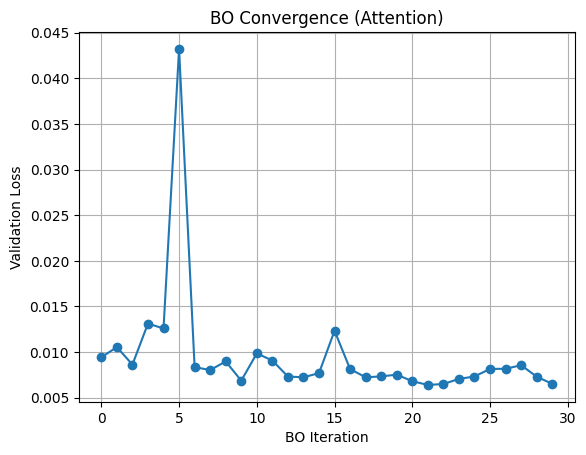

Best Attention Params: {'attn_hidden_dim': 69, 'batch_size': 111, 'dense_dropout_rate': 0.4159604493674862, 'dense_layers': 1, 'dense_units': 218, 'learning_rate': 0.006175452200065847, 'lstm_dropout_rate': 0.2786236923443287, 'lstm_layers': 2, 'units': 146}
Epoch   1 | Train 0.0905 | Val 0.0316
Epoch   2 | Train 0.0378 | Val 0.0279
Epoch   3 | Train 0.0324 | Val 0.0242
Epoch   4 | Train 0.0328 | Val 0.0214
Epoch   5 | Train 0.0299 | Val 0.0176
Epoch   6 | Train 0.0209 | Val 0.0137
Epoch   7 | Train 0.0179 | Val 0.0118
Epoch   8 | Train 0.0163 | Val 0.0124
Epoch   9 | Train 0.0134 | Val 0.0099
Epoch  10 | Train 0.0120 | Val 0.0084
Epoch  11 | Train 0.0107 | Val 0.0081
Epoch  12 | Train 0.0105 | Val 0.0075
Epoch  13 | Train 0.0102 | Val 0.0069
Epoch  14 | Train 0.0096 | Val 0.0071
Epoch  15 | Train 0.0099 | Val 0.0073
Epoch  16 | Train 0.0098 | Val 0.0080
Epoch  17 | Train 0.0091 | Val 0.0071
Epoch  18 | Train 0.0097 | Val 0.0072
Epoch  19 | Train 0.0089 | Val 0.0066
Epoch  20 | Train 0

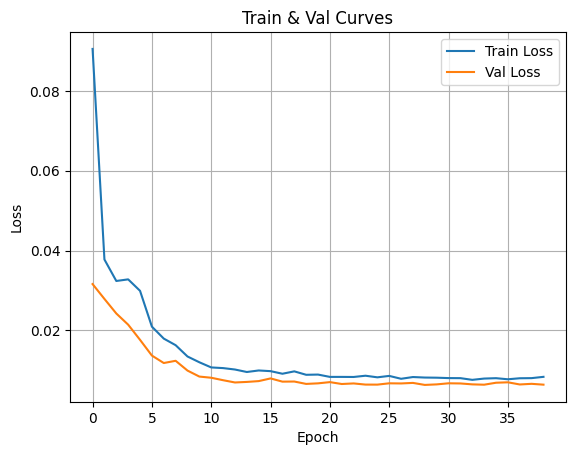

Test Loss: 0.0082
First 10 preds: [0.47221592 0.40059188 0.491979   0.84120023 0.9023707  0.8997276
 0.8671042  0.5310855  0.3912351  0.46431783]


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
import numpy as np
import math

# GPU 세팅
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled   = True

#############################################
# 1. LSTM + Bahdanau Attention 모델 정의
#############################################
class LSTM_Attention_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units,
                 lstm_dropout_rate, dense_dropout_rate, attn_hidden_dim,
                 input_features):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_features,
                            hidden_size=units,
                            num_layers=lstm_layers,
                            batch_first=True,
                            dropout=lstm_dropout_rate)
        # Bahdanau Attention 파라미터
        self.attn_W = nn.Linear(units, attn_hidden_dim)
        self.attn_U = nn.Linear(units, attn_hidden_dim)
        self.attn_v = nn.Linear(attn_hidden_dim, 1)
        # Dense 레이어
        self.dense_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(units if i==0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)
        ])
        # 출력 레이어
        out_dim = dense_units if dense_layers>0 else units
        self.output_layer = nn.Linear(out_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                    # (B, T, units)
        last_h     = lstm_out[:, -1, :]               # (B, units)
        # Attention score
        score  = torch.tanh(self.attn_W(lstm_out) +
                            self.attn_U(last_h).unsqueeze(1))  # (B, T, A)
        weights = torch.softmax(self.attn_v(score), dim=1)    # (B, T, 1)
        context = (weights * lstm_out).sum(dim=1)             # (B, units)
        # Dense → Output
        x = context
        for layer in self.dense_layers:
            x = layer(x)
        return self.output_layer(x)  # (B, 1)

#############################################
# 2. DataLoader 생성
#############################################
def create_dataloader(X, y, batch_size):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=False, num_workers=0,
                      pin_memory=True)

#############################################
# 3. Fitness 함수 (BO용)
#############################################
def fitness_attention(params, X_tr, y_tr, X_va, y_va, device):
    # unpack & round
    lstm_layers      = int(round(params['lstm_layers']))
    dense_layers     = int(round(params['dense_layers']))
    units            = int(round(params['units']))
    dense_units      = int(round(params['dense_units']))
    attn_hidden_dim  = int(round(params['attn_hidden_dim']))
    lr               = params['learning_rate']
    lstm_dr          = params['lstm_dropout_rate']
    dense_dr         = params['dense_dropout_rate']
    batch_size       = int(round(params['batch_size']))

    # model
    model = LSTM_Attention_Model(
        lstm_layers, dense_layers, units, dense_units,
        lstm_dr, dense_dr, attn_hidden_dim,
        input_features=X_tr.shape[2]
    ).to(device)

    criterion = nn.MSELoss()
    opt       = optim.AdamW(model.parameters(), lr=lr)
    loader    = create_dataloader(X_tr, y_tr, batch_size)

    # train short
    model.train()
    for _ in range(30):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb).squeeze(), yb)
            loss.backward()
            opt.step()

    # val loss
    model.eval()
    with torch.no_grad():
        val_loader = create_dataloader(X_va, y_va, batch_size)
        val_loss = 0.0
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb).squeeze(), yb).item()
    return - (val_loss / len(val_loader))  # maximize

#############################################
# 4. BO 탐색 범위 정의
#############################################
pbounds = {
    'lstm_layers':         (1, 3),
    'dense_layers':        (1, 3),
    'units':               (32, 256),
    'dense_units':         (32, 256),
    'attn_hidden_dim':     (16, 128),
    'learning_rate':       (1e-4, 1e-2),
    'lstm_dropout_rate':   (0.1, 0.5),
    'dense_dropout_rate':  (0.1, 0.5),
    'batch_size':          (16, 128),
}

optimizer_bo = BayesianOptimization(
    f=lambda **kw: fitness_attention(kw, Xtr, ytr, Xva, yva, device),
    pbounds=pbounds,
    random_state=42,
    verbose=2
)
optimizer_bo.maximize(init_points=5, n_iter=25)

# BO 수렴 곡선
iters = list(range(len(optimizer_bo.res)))
scores = [-r['target'] for r in optimizer_bo.res]
plt.figure()
plt.plot(iters, scores, marker='o')
plt.xlabel('BO Iteration')
plt.ylabel('Validation Loss')
plt.title('BO Convergence (Attention)')
plt.grid(True)
plt.show()

#############################################
# 5. 최적 파라미터 → 최종 학습 & 평가
#############################################
best = optimizer_bo.max['params']
best_params = {k: int(round(v)) if k.endswith('layers') or k.endswith('units') or k.endswith('dim') or k=='batch_size'
               else v for k,v in best.items()}
print("Best Attention Params:", best_params)

# 최종 모델
model = LSTM_Attention_Model(
    lstm_layers         = best_params['lstm_layers'],
    dense_layers        = best_params['dense_layers'],
    units               = best_params['units'],
    dense_units         = best_params['dense_units'],
    lstm_dropout_rate   = best_params['lstm_dropout_rate'],
    dense_dropout_rate  = best_params['dense_dropout_rate'],
    attn_hidden_dim     = best_params['attn_hidden_dim'],
    input_features      = Xtr.shape[2]
).to(device)

opt = optim.AdamW(model.parameters(), lr=best_params['learning_rate'])
scheduler = StepLR(opt, step_size=10, gamma=0.5)

train_loader = create_dataloader(Xtr, ytr, best_params['batch_size'])
val_loader   = create_dataloader(Xva, yva, best_params['batch_size'])
test_loader  = create_dataloader(Xte, yte, best_params['batch_size'])

train_losses, val_losses = [], []
best_val, counter, patience = float('inf'), 0, 10

for epoch in range(1,151):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = nn.MSELoss()(model(xb).squeeze(), yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    scheduler.step()

    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vloss += nn.MSELoss()(model(xb).squeeze(), yb).item()
    vloss /= len(val_loader)

    train_losses.append(epoch_loss/len(train_loader))
    val_losses.append(vloss)
    print(f"Epoch {epoch:3d} | Train {train_losses[-1]:.4f} | Val {vloss:.4f}")

    if vloss < best_val:
        best_val, counter = vloss, 0
    else:
        counter += 1
        if counter>=patience:
            print(f"Early stopping at epoch {epoch}")
            break

# 학습/검증 곡선
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Train & Val Curves')
plt.legend(); plt.grid(True); plt.show()

# Test 평가
model.eval()
tloss = 0.0; preds=[]
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        p = model(xb).squeeze()
        preds.append(p.cpu().numpy())
        tloss += nn.MSELoss()(p, yb).item()
tloss /= len(test_loader)
preds = np.concatenate(preds,axis=0)

print(f"Test Loss: {tloss:.4f}")
print("First 10 preds:", preds[:10])


314


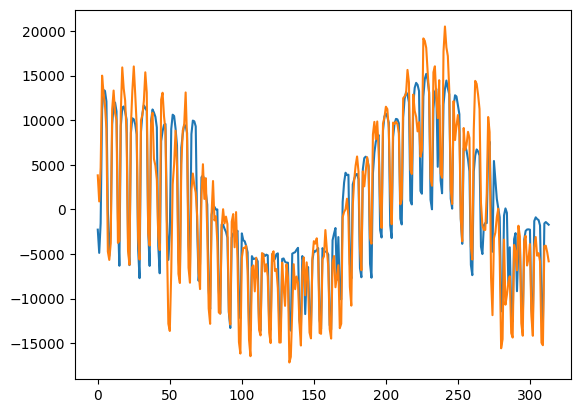

In [61]:
# 
inverse_pred1 = mny1.inverse_transform(preds.reshape(-1,1))
inverse_real1 =  mny1.inverse_transform(yte.reshape(-1,1))

# 
plt.plot(inverse_pred1)
plt.plot(inverse_real1)

# trend arima_preds
print(len(inverse_pred1))

In [74]:
len(arima_preds)

# 결과 합치기
sum_data = arima_preds[-len(inverse_real1.flatten()):]  + inverse_pred1.flatten() + inverse_pred.flatten()

r2 score : 0.89
mape : 0.03
rmse : 3238.67


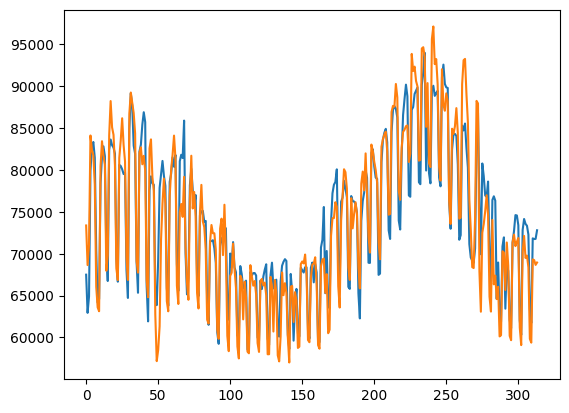

In [82]:
plt.plot(sum_data)
plt.plot(result_df["max_power"][-len(sum_data):].values)

# 설명력 등 확인 필요
from sklearn.metrics import r2_score, mean_absolute_percentage_error, root_mean_squared_error

# 체크
real = result_df["max_power"][-len(sum_data):].values

# 
r2 = np.round(r2_score(real, sum_data),2)
mape = np.round(mean_absolute_percentage_error(real, sum_data),2)
rmse = np.round(root_mean_squared_error(real, sum_data),2)

print(f"r2 score : {r2}")
print(f"mape : {mape}")
print(f"rmse : {rmse}")

# ARIMA 사용

# ㅣLSTM